IPL 2022 Capstone Project

The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.

These are some of the important columns that we'll focus on for meaningful insights in this project.

column names: Variable Type

date : string venue : string stage : string team1 : string team2 : string toss_winner : string toss_decision : string first_ings_score : integer second_ings_score : integer match_winner : string won_by : string margin : integer player_of_the_match : string top_scorer : string highscore : integer best_bowling : string best_bowling_fgure : string gure : string

Loading Libraries and Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("IPL.csv")
df.head()

Matplotlib is building the font cache; this may take a moment.


,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


Basic Information

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

Check the size of rows and colm

In [5]:
df.shape
print(f"The data set has {df.shape[0]} rows and {df.shape[1]} colm")

The data set has 74 rows and 20 colm


How many colms has null values in total

In [8]:
df.isnull()
# is sum will make all true values as 1 and false has  0 
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

Which team has won the most matches

Text(0, 0.5, 'teams')

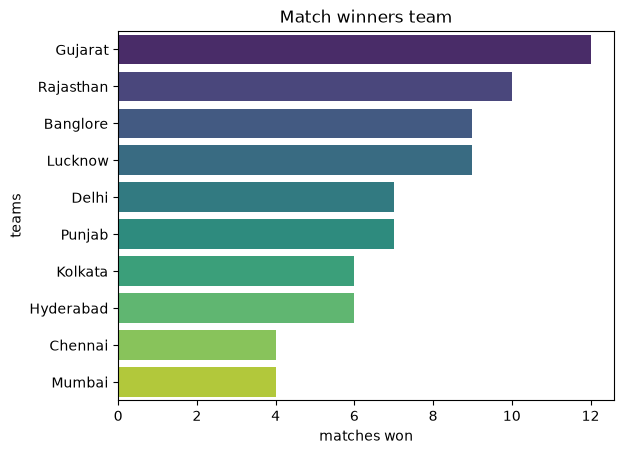

In [ ]:
matchwinners = df['match_winner'].value_counts()
# value count returns a series which contain indexes as well as their values.
matchwinners
sns.barplot(y=matchwinners.index ,  x = matchwinners.values , palette="viridis")
plt.title("Match winners team")
plt.xlabel("matches won")
plt.ylabel("teams")

Toss decision trends

Text(0.5, 1.0, 'Toss decision trends')

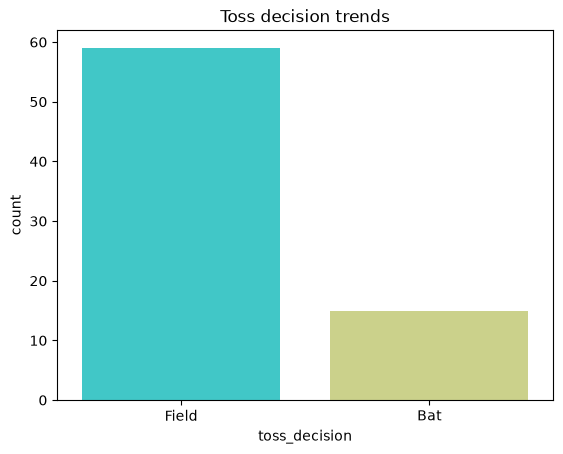

In [24]:
# we just want to know how many chooses bat or bowl so we can use countplot here

sns.countplot(x=df["toss_decision"] , palette="rainbow")
plt.title("Toss decision trends")

Toss Winner vs Match Winner

In [31]:
count = df[df['toss_winner']== df["match_winner"]]['match_id'].count()
percentage = count*100/df.shape[0]
percentage.round(2)

np.float64(48.65)

How do team won (Run vs Wickets)

<Axes: xlabel='won_by', ylabel='count'>

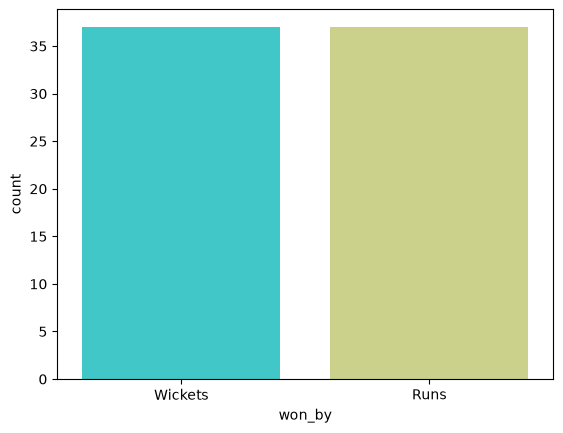

In [33]:
sns.countplot(x=df['won_by'],palette="rainbow")

Key Player Performances

1.Most player of the match awards

Text(0.5, 1.0, 'man of the match')

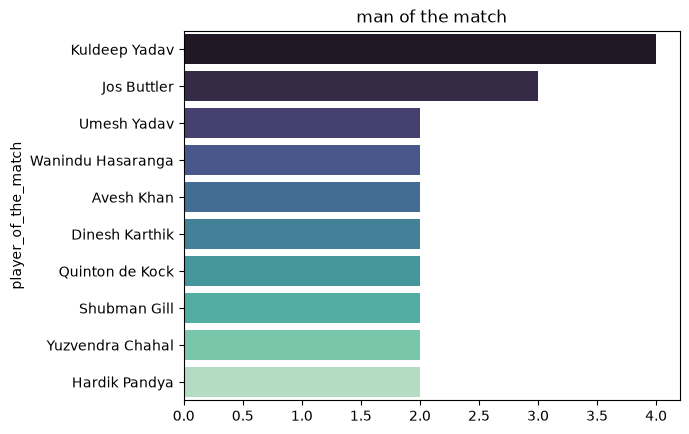

In [41]:
df.head()
count = df['player_of_the_match'].value_counts().head(10)
sns.barplot(y=count.index,x=count.values,palette="mako")
plt.title("man of the match")

Top 2 highest scorer

<Axes: ylabel='top_scorer'>

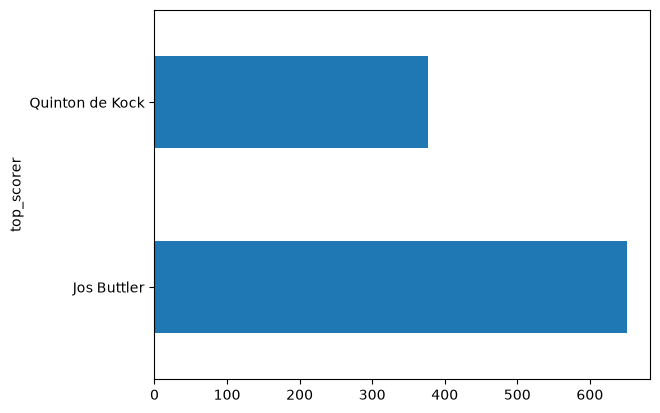

In [ ]:
# here we have to deal with two values i.e highscore as well as top_scorer so in these type of situations we do use group by

high = df.groupby("top_scorer")['highscore'].sum().sort_values(ascending=False).head(2)
# lets draw bar graph using matplotlib here
high.plot(kind="barh")  #h is for horizontal

Best bowling Figure

In [50]:
df.head(3)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59


Text(0.5, 1.0, 'Highest Wicket Taker')

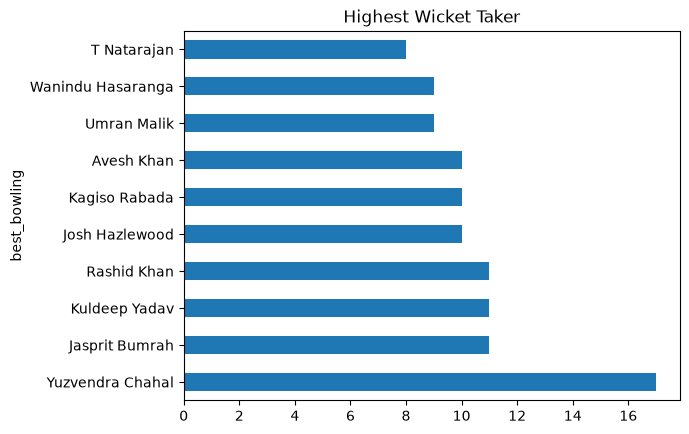

In [64]:
# now we have to extract wickets from best bowling figure
df['highest_wicket'] = df['best_bowling_figure'].apply(lambda x : x.split('--')[0])
df['highest_wicket']=df['highest_wicket'].astype(int)
top_bowler = df.groupby('best_bowling')['highest_wicket'].sum().sort_values(ascending=False).head(10)
top_bowler.plot(kind="barh")
plt.title("Highest Wicket Taker")

Venue Analysis

Most matches played by venue

<Axes: ylabel='venue'>

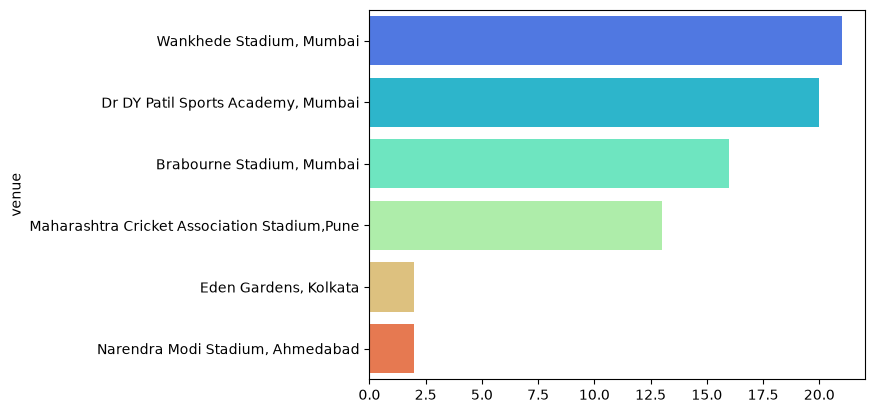

In [70]:
venue_count = df['venue'].value_counts()
sns.barplot(y=venue_count.index , x=venue_count.values,palette='rainbow')

Custom Questions and Insights

Who won the highest margin by runs

In [79]:
df[df['won_by'] == 'Runs'].sort_values(by="margin" , ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


Which player had the highest individual score

In [88]:
df[df['highscore']==df['highscore'].max()][['top_scorer',"highscore"]]

,top_scorer,highscore
65,Quinton de Kock,140


Which bowler had the best bowling Figure

In [92]:
df[df['highest_wicket']==df['highest_wicket'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
